In [1]:
# =============================================================
# ERA COMPARISON PROJECT - Notebook 1: Data Exploration
# Goal: Download real market data and understand its structure
#       before building any trading strategy.
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We select 5 stocks from different sectors to get a broad view
# of the market. This helps us avoid conclusions that only apply
# to one specific industry.
# AAPL = Technology, JPM = Finance, AMZN = Consumer, 
# XOM = Energy, JNJ = Healthcare
tickers = ['AAPL', 'JPM', 'AMZN', 'XOM', 'JNJ']

# Download 10 years of daily price data
# yfinance pulls directly from Yahoo Finance - no API key needed
data = yf.download(tickers, start='2014-01-01', end='2024-01-01')

# We only use the closing price (price at end of each trading day)
# Other columns like Open, High, Low are not needed for this project
prices = data['Close']

print(f"Dataset shape: {prices.shape}")  # (trading days, number of stocks)
print(prices.head())

[*********************100%***********************]  5 of 5 completed

Dataset shape: (2516, 5)
Ticker           AAPL       AMZN        JNJ        JPM        XOM
Date                                                             
2014-01-02  17.124882  19.898500  64.499298  41.982849  59.712341
2014-01-03  16.748720  19.822001  65.080307  42.307396  59.568665
2014-01-06  16.840054  19.681499  65.420387  42.552612  59.658482
2014-01-07  16.719618  19.901501  66.809158  42.062180  60.502510
2014-01-08  16.825502  20.096001  66.717033  42.458855  60.304970


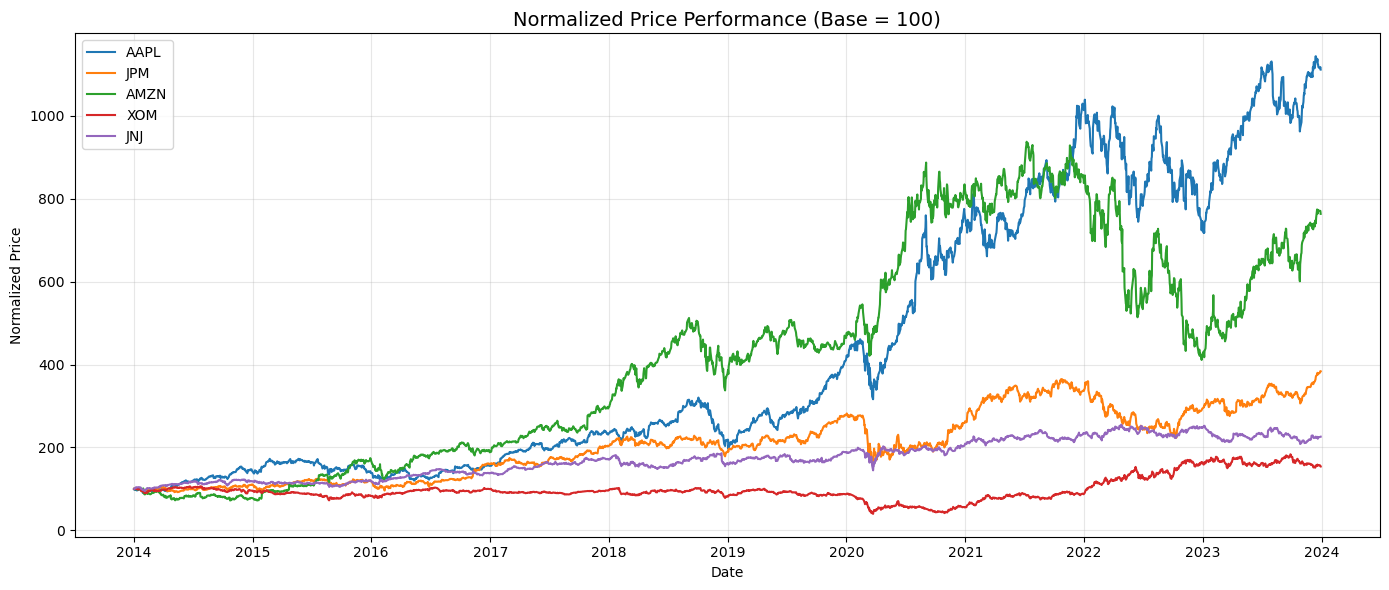

In [2]:
# -------------------------------------------------------------
# NORMALIZED PRICE CHART
# Problem: AAPL trades at ~$150 and AMZN at ~$3000, so plotting
# raw prices makes comparison impossible.
# Solution: Normalize everything to 100 at the start date.
# Now the chart shows % growth, not absolute price.
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))

for ticker in tickers:
    # Divide every price by the first price, then multiply by 100
    # Result: all stocks start at 100, easy to compare growth rates
    normalized = prices[ticker] / prices[ticker].iloc[0] * 100
    ax.plot(normalized, label=ticker)

ax.set_title('Normalized Price Performance (Base = 100)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/01_price_performance.png', dpi=150)
plt.show()

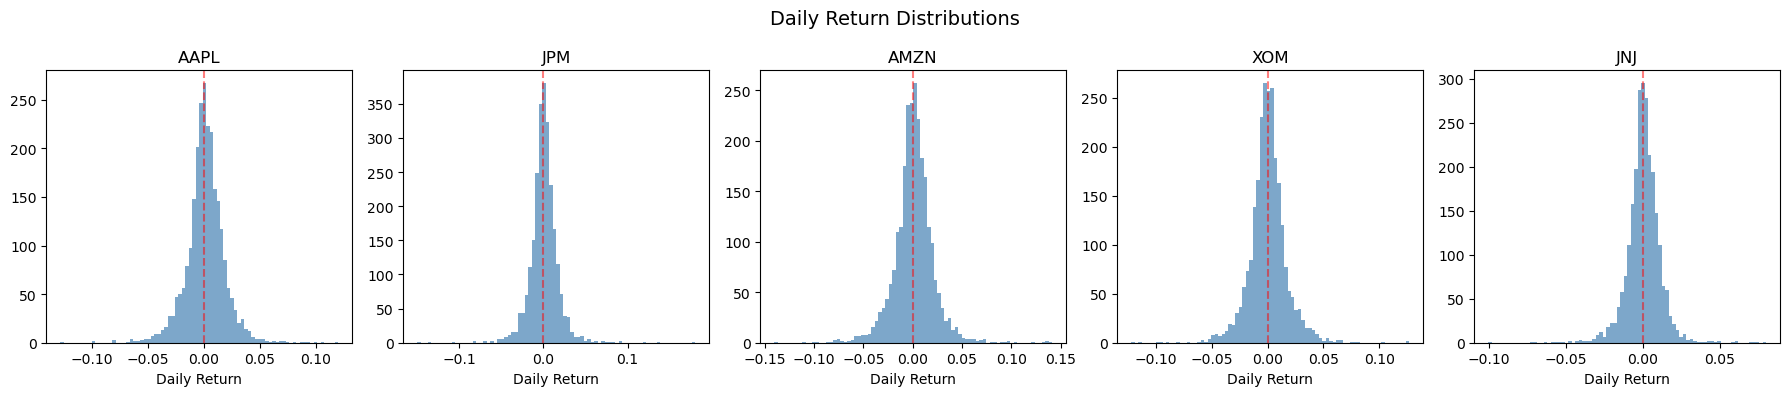

In [3]:
# -------------------------------------------------------------
# DAILY RETURN DISTRIBUTIONS
# Instead of looking at price levels, we look at daily returns:
#   return_t = (price_t - price_{t-1}) / price_{t-1}
# This tells us: "how much did the stock move today?"
#
# What to look for in these histograms:
# - Most returns cluster near 0 (small daily moves are common)
# - The tails extend further than a normal distribution would predict
#   This is called "fat tails" - extreme events happen more often
#   than classical models assume. This matters a lot for risk.
# -------------------------------------------------------------

returns = prices.pct_change().dropna()  # pct_change() computes daily returns

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ticker in enumerate(tickers):
    axes[i].hist(returns[ticker], bins=80, color='steelblue', alpha=0.7)
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Daily Return')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Daily Return Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../results/02_return_distributions.png', dpi=150)
plt.show()

In [4]:
# -------------------------------------------------------------
# SUMMARY STATISTICS
#
# Key metrics explained:
# - mean: average daily return (small positive = generally going up)
# - std: standard deviation = how volatile the stock is day-to-day
# - min/max: the worst and best single days in 10 years
# - Annualized volatility: std * sqrt(252) 
#   (252 = number of trading days per year)
#   This converts daily volatility to a yearly figure for comparison
#
# Correlation matrix: measures how much two stocks move together
# - 1.0 = always move in the same direction
# - 0.0 = completely independent
# - Negative = move in opposite directions
# Low correlation between stocks is good for diversification
# -------------------------------------------------------------

print("=== Basic Statistics ===")
print(returns.describe().round(4))

print("\n=== Annualized Volatility ===")
# Multiply daily std by sqrt(252) to annualize
# This is standard practice in finance
print((returns.std() * np.sqrt(252)).round(4))

print("\n=== Correlation Matrix ===")
print(returns.corr().round(2))

=== Basic Statistics ===
Ticker       AAPL       AMZN        JNJ        JPM        XOM
count   2515.0000  2515.0000  2515.0000  2515.0000  2515.0000
mean       0.0011     0.0010     0.0004     0.0007     0.0003
std        0.0179     0.0209     0.0113     0.0170     0.0174
min       -0.1286    -0.1405    -0.1004    -0.1496    -0.1222
25%       -0.0071    -0.0087    -0.0048    -0.0072    -0.0079
50%        0.0009     0.0011     0.0003     0.0005     0.0001
75%        0.0102     0.0112     0.0060     0.0084     0.0085
max        0.1198     0.1413     0.0800     0.1801     0.1269

=== Annualized Volatility ===
Ticker
AAPL    0.2838
AMZN    0.3317
JNJ     0.1800
JPM     0.2694
XOM     0.2761
dtype: float64

=== Correlation Matrix ===
Ticker  AAPL  AMZN   JNJ   JPM   XOM
Ticker                              
AAPL    1.00  0.54  0.37  0.44  0.32
AMZN    0.54  1.00  0.25  0.30  0.20
JNJ     0.37  0.25  1.00  0.41  0.34
JPM     0.44  0.30  0.41  1.00  0.57
XOM     0.32  0.20  0.34  0.57  1.00
